In [ ]:
!pip install cartopy

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

!ls "/content/drive/My Drive/Course Lectures/OCN 2102 Physical Oceanography Lab"

Mounted at /content/drive/
 Lab-01_Intro_to_data.ipynb
 Lab-02_Python_Fundamentals.ipynb
 Lab-03_Functions_Classes.ipynb
 OCN-2102_Lab_Final.docx
 OCN-2102_Lab_Final.pdf
'OCN-2102 Lab Viva.xlsx'
 OCN-2102_phys_BoB-monthly_2015-2022.nc
 OCN-2102_phys_Hudson_Bay-monthly_2015-2022.nc
'OCN-2102-Physical Oceanography Lab.docx'
'OCN-2102-Physical Oceanography Lab.pdf'


In [ ]:
# Define the paths to the NetCDF filesHadISST_Sea_Ice_1870-2023.nc
path = "/content/drive/My Drive/Course Lectures/OCN 2102 Physical Oceanography Lab/OCN-2102_phys_BoB-monthly_2015-2022.nc"

# Open the files and store them in a Python variable
ds = xr.open_dataset(path)

In [ ]:
ds

<xarray.Dataset> Size: 797MB
Dimensions:    (time: 216, depth: 26, latitude: 80, longitude: 88)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2005-01-01 2005-02-01 ... 2022-12-01
  * depth      (depth) float32 104B -0.0 5.0 10.0 15.0 ... 250.0 275.0 300.0
  * latitude   (latitude) float32 320B 5.125 5.375 5.625 ... 24.38 24.62 24.88
  * longitude  (longitude) float32 352B 78.12 78.38 78.62 ... 99.38 99.62 99.88
Data variables:
    so         (time, depth, latitude, longitude) float32 158MB ...
    to         (time, depth, latitude, longitude) float32 158MB ...
    ugo        (time, depth, latitude, longitude) float32 158MB ...
    vgo        (time, depth, latitude, longitude) float32 158MB ...
    zo         (time, depth, latitude, longitude) float32 158MB ...
    mlotst     (time, latitude, longitude) float32 6MB ...
Attributes:
    Conventions:       CF-1.11
    title:             ARMOR3D REP - TSHUVMld Global Ocean Observation-based ...
    institution:       CLS
    history:           1993-01-15 12:00:00 ARMOR3D REP - TSHUV Global Ocean O...
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  MULTIOBS_GLO_PHY_TSUV_3D_MYNRT_015_012
    subset:datasetId:  dataset-armor-3d-rep-monthly_202012
    subset:date:       2025-04-14T08:35:06.363Z

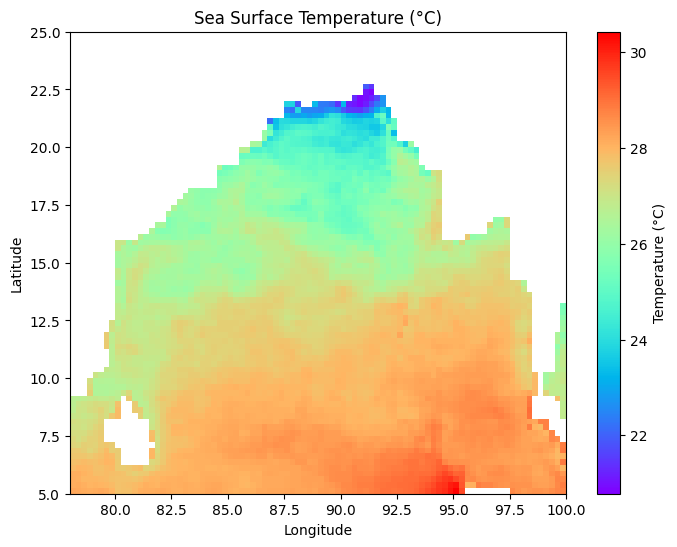

In [ ]:
# Select time step
time_idx = 0

# Select surface temperature (depth = 0)
surface_temperature = ds['to'].sel(
    time=ds['time'][time_idx],
    depth=0  # assuming exact 0m depth exists
)

# Select geographic region
surface_temperature = surface_temperature.sel(latitude=slice(5, 25), longitude=slice(78, 100))

# Plotting
plt.figure(figsize=(8, 6))

temp_plot = plt.pcolormesh(
    surface_temperature['longitude'], surface_temperature['latitude'],
    surface_temperature, shading='auto', cmap='rainbow'
)
plt.title('Sea Surface Temperature (°C)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
cbar = plt.colorbar(temp_plot)
cbar.set_label('Temperature (°C)')

plt.show()

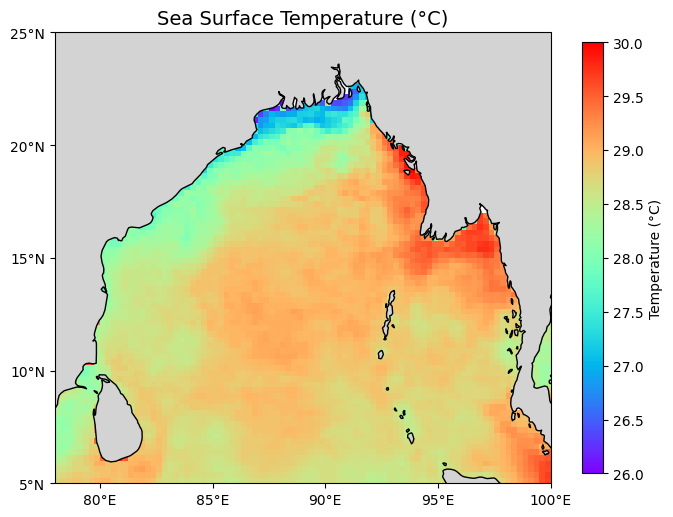

In [ ]:
# Select surface temperature at a specific date
surface_temperature = ds['to'].sel(
    time='2022-11-01',
    depth=0
)

# Select geographic region
surface_temperature = surface_temperature.sel(latitude=slice(5, 25), longitude=slice(78, 100))

# Plotting
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([78, 100, 5, 25], crs=ccrs.PlateCarree())

# Plot SST first
temp_plot = ax.pcolormesh(
    surface_temperature['longitude'], surface_temperature['latitude'],
    surface_temperature, shading='auto', cmap='rainbow', transform=ccrs.PlateCarree(),
    vmin=26, vmax=30, zorder=1
)

# Then plot land ABOVE
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax.add_feature(cfeature.COASTLINE, zorder=3)

# Set ticks manually
ax.set_xticks([80, 85, 90, 95, 100], crs=ccrs.PlateCarree())
ax.set_yticks([5, 10, 15, 20, 25], crs=ccrs.PlateCarree())

# Format ticks
lon_formatter = ccrs.cartopy.mpl.ticker.LongitudeFormatter()
lat_formatter = ccrs.cartopy.mpl.ticker.LatitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)

# Titles and colorbar
plt.title('Sea Surface Temperature (°C)', fontsize=14)
cbar = plt.colorbar(temp_plot, ax=ax, orientation='vertical', shrink=0.7, label='Temperature (°C)')

plt.show()

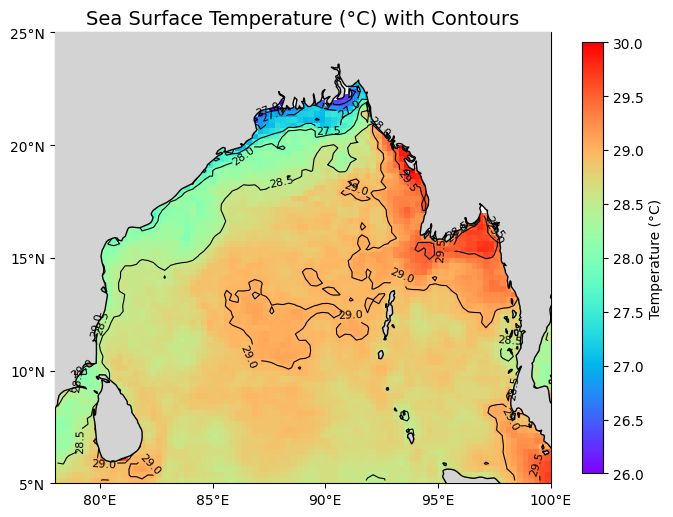

In [ ]:
import numpy as np

# Select surface temperature at a specific date
surface_temperature = ds['to'].sel(
    time='2022-11-01',
    depth=0
)

# Select geographic region
surface_temperature = surface_temperature.sel(latitude=slice(5, 25), longitude=slice(78, 100))

# Plotting
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([78, 100, 5, 25], crs=ccrs.PlateCarree())

# Plot SST as color map
temp_plot = ax.pcolormesh(
    surface_temperature['longitude'], surface_temperature['latitude'],
    surface_temperature, shading='auto', cmap='rainbow', transform=ccrs.PlateCarree(),
    vmin=26, vmax=30, zorder=1
)

# Add SST contours with defined range and interval
temp_contours = ax.contour(
    surface_temperature['longitude'], surface_temperature['latitude'],
    surface_temperature, levels=np.arange(26, 30.5, 0.5),  # From 26 to 30 with 0.5 interval
    colors='black', linewidths=0.8, transform=ccrs.PlateCarree(), zorder=2
)
ax.clabel(temp_contours, inline=True, fontsize=8, fmt="%.1f")

# Plot land and coastline
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
ax.add_feature(cfeature.COASTLINE, zorder=4)

# Set ticks manually
ax.set_xticks([80, 85, 90, 95, 100], crs=ccrs.PlateCarree())
ax.set_yticks([5, 10, 15, 20, 25], crs=ccrs.PlateCarree())

# Format ticks
lon_formatter = ccrs.cartopy.mpl.ticker.LongitudeFormatter()
lat_formatter = ccrs.cartopy.mpl.ticker.LatitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)

# Titles and colorbar
plt.title('Sea Surface Temperature (°C) with Contours', fontsize=14)
cbar = plt.colorbar(temp_plot, ax=ax, orientation='vertical', shrink=0.7, label='Temperature (°C)')

plt.show()

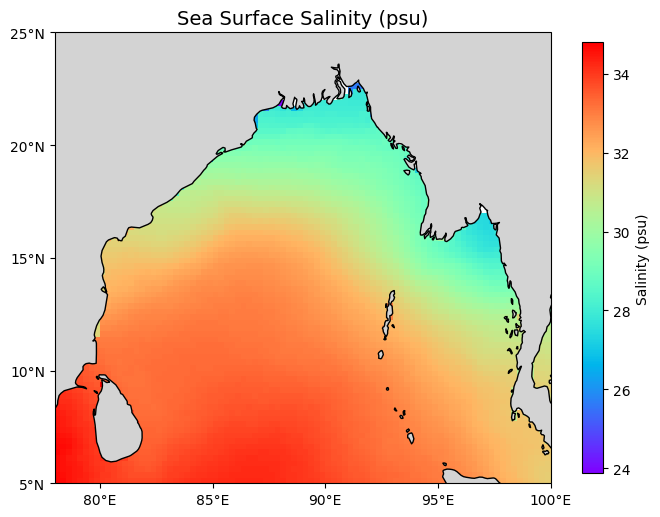

In [ ]:
# Select surface salinity at a specific date
surface_salinity = ds['so'].sel(
    time='2022-11-01',
    depth=0
)

# Select geographic region
surface_salinity = surface_salinity.sel(latitude=slice(5, 25), longitude=slice(78, 100))

# Plotting
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([78, 100, 5, 25], crs=ccrs.PlateCarree())

# Plot salinity first
salinity_plot = ax.pcolormesh(
    surface_salinity['longitude'], surface_salinity['latitude'],
    surface_salinity, shading='auto', cmap='rainbow', transform=ccrs.PlateCarree(), zorder=1
)

# Then plot land ABOVE
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax.add_feature(cfeature.COASTLINE, zorder=3)

# Set ticks manually
ax.set_xticks([80, 85, 90, 95, 100], crs=ccrs.PlateCarree())
ax.set_yticks([5, 10, 15, 20, 25], crs=ccrs.PlateCarree())

# Format ticks
lon_formatter = LongitudeFormatter()
lat_formatter = LatitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)

# Titles and colorbar
plt.title('Sea Surface Salinity (psu)', fontsize=14)
cbar = plt.colorbar(salinity_plot, ax=ax, orientation='vertical', shrink=0.7, label='Salinity (psu)')

plt.show()

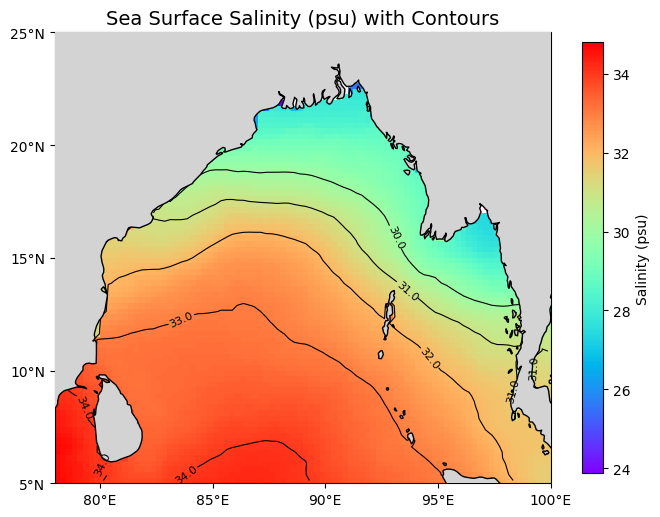

In [ ]:
import numpy as np

# Select surface salinity at a specific date
surface_salinity = ds['so'].sel(
    time='2022-11-01',
    depth=0
)

# Select geographic region
surface_salinity = surface_salinity.sel(latitude=slice(5, 25), longitude=slice(78, 100))

# Plotting
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([78, 100, 5, 25], crs=ccrs.PlateCarree())

# Plot salinity first
salinity_plot = ax.pcolormesh(
    surface_salinity['longitude'], surface_salinity['latitude'],
    surface_salinity, shading='auto', cmap='rainbow', transform=ccrs.PlateCarree(), zorder=1
)

# Add salinity contours with defined range and interval
salinity_contours = ax.contour(
    surface_salinity['longitude'], surface_salinity['latitude'],
    surface_salinity, levels=np.arange(30, 36, 1),  # From 30 to 36 with 1 interval
    colors='black', linewidths=0.8, transform=ccrs.PlateCarree(), zorder=2
)
ax.clabel(salinity_contours, inline=True, fontsize=8, fmt="%.1f")

# Then plot land ABOVE
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
ax.add_feature(cfeature.COASTLINE, zorder=4)

# Set ticks manually
ax.set_xticks([80, 85, 90, 95, 100], crs=ccrs.PlateCarree())
ax.set_yticks([5, 10, 15, 20, 25], crs=ccrs.PlateCarree())

# Format ticks
lon_formatter = LongitudeFormatter()
lat_formatter = LatitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)

# Titles and colorbar
plt.title('Sea Surface Salinity (psu) with Contours', fontsize=14)
cbar = plt.colorbar(salinity_plot, ax=ax, orientation='vertical', shrink=0.7, label='Salinity (psu)')

plt.show()


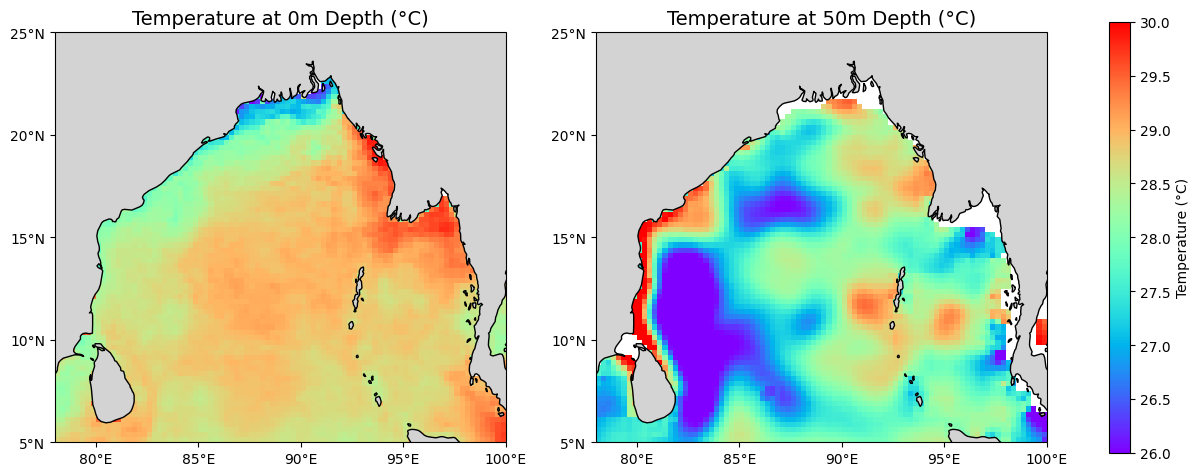

In [ ]:
# Select temperature at 0m and 50m depth for a specific date
temperature_0m = ds['to'].sel(time='2022-11-01', depth=0)
temperature_50m = ds['to'].sel(time='2022-11-01', depth=50)

# Select geographic region
temperature_0m = temperature_0m.sel(latitude=slice(5, 25), longitude=slice(78, 100))
temperature_50m = temperature_50m.sel(latitude=slice(5, 25), longitude=slice(78, 100))

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot 0m depth
ax1.set_extent([78, 100, 5, 25], crs=ccrs.PlateCarree())

temp_plot_0m = ax1.pcolormesh(
    temperature_0m['longitude'], temperature_0m['latitude'],
    temperature_0m, shading='auto', cmap='rainbow', transform=ccrs.PlateCarree(),
    vmin=26, vmax=30, zorder=1
)

ax1.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax1.add_feature(cfeature.COASTLINE, zorder=3)

ax1.set_xticks([80, 85, 90, 95, 100], crs=ccrs.PlateCarree())
ax1.set_yticks([5, 10, 15, 20, 25], crs=ccrs.PlateCarree())

lon_formatter = ccrs.cartopy.mpl.ticker.LongitudeFormatter()
lat_formatter = ccrs.cartopy.mpl.ticker.LatitudeFormatter()
ax1.xaxis.set_major_formatter(lon_formatter)
ax1.yaxis.set_major_formatter(lat_formatter)

ax1.set_title('Temperature at 0m Depth (°C)', fontsize=14)

# Plot 50m depth
ax2.set_extent([78, 100, 5, 25], crs=ccrs.PlateCarree())

temp_plot_50m = ax2.pcolormesh(
    temperature_50m['longitude'], temperature_50m['latitude'],
    temperature_50m, shading='auto', cmap='rainbow', transform=ccrs.PlateCarree(),
    vmin=26, vmax=30, zorder=1
)

ax2.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax2.add_feature(cfeature.COASTLINE, zorder=3)

ax2.set_xticks([80, 85, 90, 95, 100], crs=ccrs.PlateCarree())
ax2.set_yticks([5, 10, 15, 20, 25], crs=ccrs.PlateCarree())

ax2.xaxis.set_major_formatter(lon_formatter)
ax2.yaxis.set_major_formatter(lat_formatter)

ax2.set_title('Temperature at 50m Depth (°C)', fontsize=14)

# Colorbar
cbar = plt.colorbar(temp_plot_50m, ax=[ax1, ax2], orientation='vertical', shrink=0.7, label='Temperature (°C)')

plt.show()


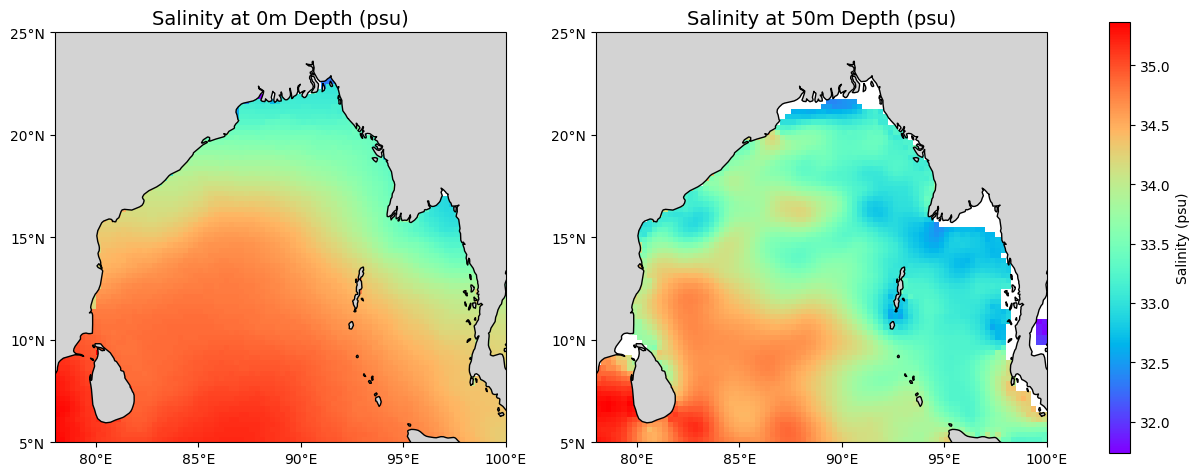

In [ ]:
# Select salinity at 0m and 50m depth for a specific date
salinity_0m = ds['so'].sel(time='2022-11-01', depth=0)
salinity_50m = ds['so'].sel(time='2022-11-01', depth=50)

# Select geographic region
salinity_0m = salinity_0m.sel(latitude=slice(5, 25), longitude=slice(78, 100))
salinity_50m = salinity_50m.sel(latitude=slice(5, 25), longitude=slice(78, 100))

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot 0m depth
ax1.set_extent([78, 100, 5, 25], crs=ccrs.PlateCarree())

salinity_plot_0m = ax1.pcolormesh(
    salinity_0m['longitude'], salinity_0m['latitude'],
    salinity_0m, shading='auto', cmap='rainbow', transform=ccrs.PlateCarree(), zorder=1
)

ax1.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax1.add_feature(cfeature.COASTLINE, zorder=3)

ax1.set_xticks([80, 85, 90, 95, 100], crs=ccrs.PlateCarree())
ax1.set_yticks([5, 10, 15, 20, 25], crs=ccrs.PlateCarree())

lon_formatter = LongitudeFormatter()
lat_formatter = LatitudeFormatter()
ax1.xaxis.set_major_formatter(lon_formatter)
ax1.yaxis.set_major_formatter(lat_formatter)

ax1.set_title('Salinity at 0m Depth (psu)', fontsize=14)

# Plot 50m depth
ax2.set_extent([78, 100, 5, 25], crs=ccrs.PlateCarree())

salinity_plot_50m = ax2.pcolormesh(
    salinity_50m['longitude'], salinity_50m['latitude'],
    salinity_50m, shading='auto', cmap='rainbow', transform=ccrs.PlateCarree(), zorder=1
)

ax2.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax2.add_feature(cfeature.COASTLINE, zorder=3)

ax2.set_xticks([80, 85, 90, 95, 100], crs=ccrs.PlateCarree())
ax2.set_yticks([5, 10, 15, 20, 25], crs=ccrs.PlateCarree())

ax2.xaxis.set_major_formatter(lon_formatter)
ax2.yaxis.set_major_formatter(lat_formatter)

ax2.set_title('Salinity at 50m Depth (psu)', fontsize=14)

# Colorbar
cbar = plt.colorbar(salinity_plot_50m, ax=[ax1, ax2], orientation='vertical', shrink=0.7, label='Salinity (psu)')

plt.show()


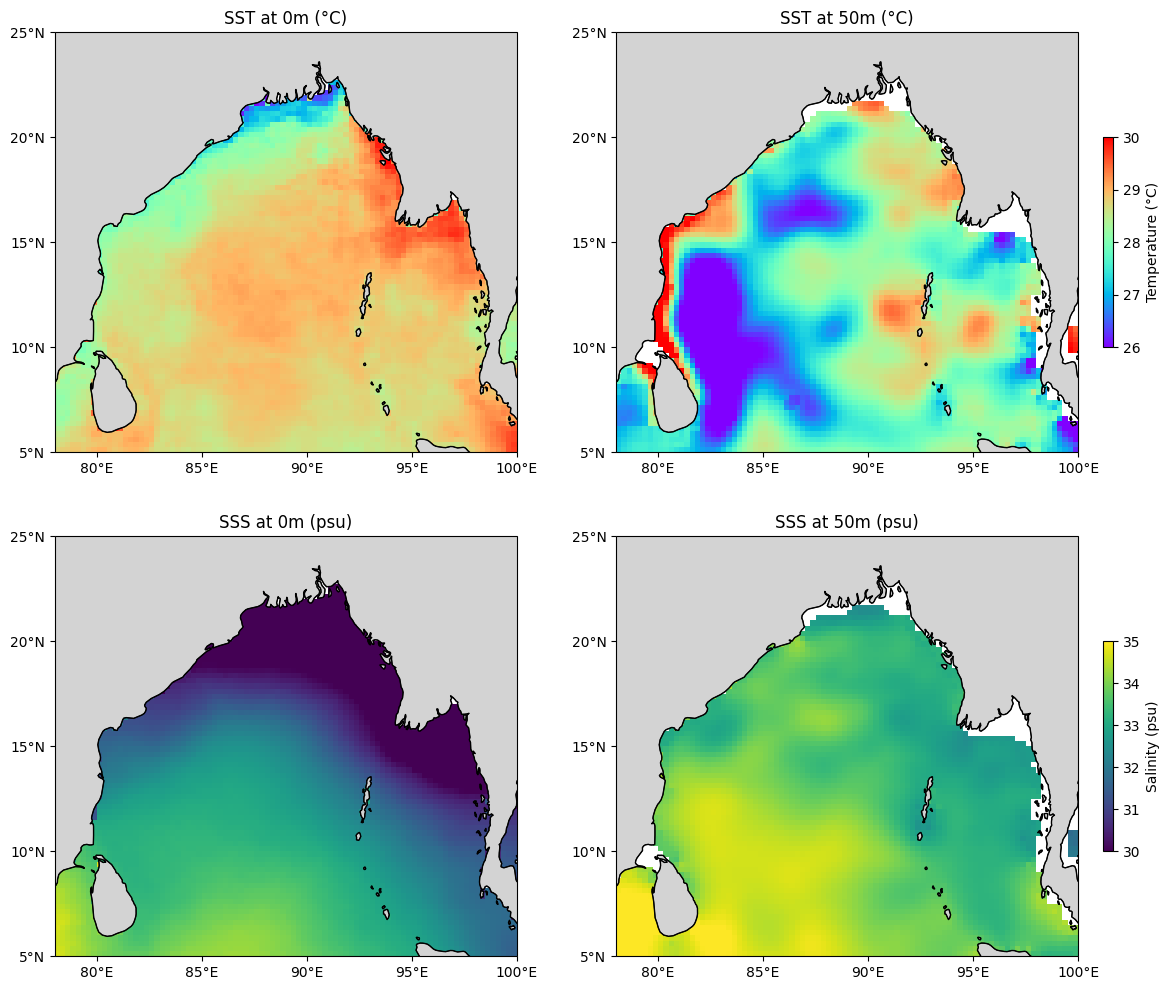

In [ ]:
# Select temperature and salinity at 0m and 50m for a specific date
temp_0m = ds['to'].sel(time='2022-11-01', depth=0).sel(latitude=slice(5, 25), longitude=slice(78, 100))
temp_50m = ds['to'].sel(time='2022-11-01', depth=50).sel(latitude=slice(5, 25), longitude=slice(78, 100))
sal_0m = ds['so'].sel(time='2022-11-01', depth=0).sel(latitude=slice(5, 25), longitude=slice(78, 100))
sal_50m = ds['so'].sel(time='2022-11-01', depth=50).sel(latitude=slice(5, 25), longitude=slice(78, 100))

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(16, 12), subplot_kw={'projection': ccrs.PlateCarree()})

# Helper function to format each subplot
def format_ax(ax):
    ax.set_extent([78, 100, 5, 25], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=3)
    ax.set_xticks([80, 85, 90, 95, 100], crs=ccrs.PlateCarree())
    ax.set_yticks([5, 10, 15, 20, 25], crs=ccrs.PlateCarree())
    lon_formatter = ccrs.cartopy.mpl.ticker.LongitudeFormatter()
    lat_formatter = ccrs.cartopy.mpl.ticker.LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)

# Panel 1: SST at 0m
ax = axs[0, 0]
temp_plot_0 = ax.pcolormesh(temp_0m['longitude'], temp_0m['latitude'], temp_0m,
                            shading='auto', cmap='rainbow', transform=ccrs.PlateCarree(),
                            vmin=26, vmax=30, zorder=1)
ax.set_title('SST at 0m (°C)', fontsize=12)
format_ax(ax)

# Panel 2: SST at 50m
ax = axs[0, 1]
temp_plot_50 = ax.pcolormesh(temp_50m['longitude'], temp_50m['latitude'], temp_50m,
                             shading='auto', cmap='rainbow', transform=ccrs.PlateCarree(),
                             vmin=26, vmax=30, zorder=1)
ax.set_title('SST at 50m (°C)', fontsize=12)
format_ax(ax)

# Panel 3: SSS at 0m
ax = axs[1, 0]
sal_plot_0 = ax.pcolormesh(sal_0m['longitude'], sal_0m['latitude'], sal_0m,
                           shading='auto', cmap='viridis', transform=ccrs.PlateCarree(),
                           vmin=30, vmax=35, zorder=1)
ax.set_title('SSS at 0m (psu)', fontsize=12)
format_ax(ax)

# Panel 4: SSS at 50m
ax = axs[1, 1]
sal_plot_50 = ax.pcolormesh(sal_50m['longitude'], sal_50m['latitude'], sal_50m,
                            shading='auto', cmap='viridis', transform=ccrs.PlateCarree(),
                            vmin=30, vmax=35, zorder=1)
ax.set_title('SSS at 50m (psu)', fontsize=12)
format_ax(ax)

# Add individual colorbars to the right of each row
fig.colorbar(temp_plot_0, ax=axs[0, :], orientation='vertical', shrink=0.5, pad=0.02, label='Temperature (°C)')
fig.colorbar(sal_plot_0, ax=axs[1, :], orientation='vertical', shrink=0.5, pad=0.02, label='Salinity (psu)')

# Show the plot
plt.show()


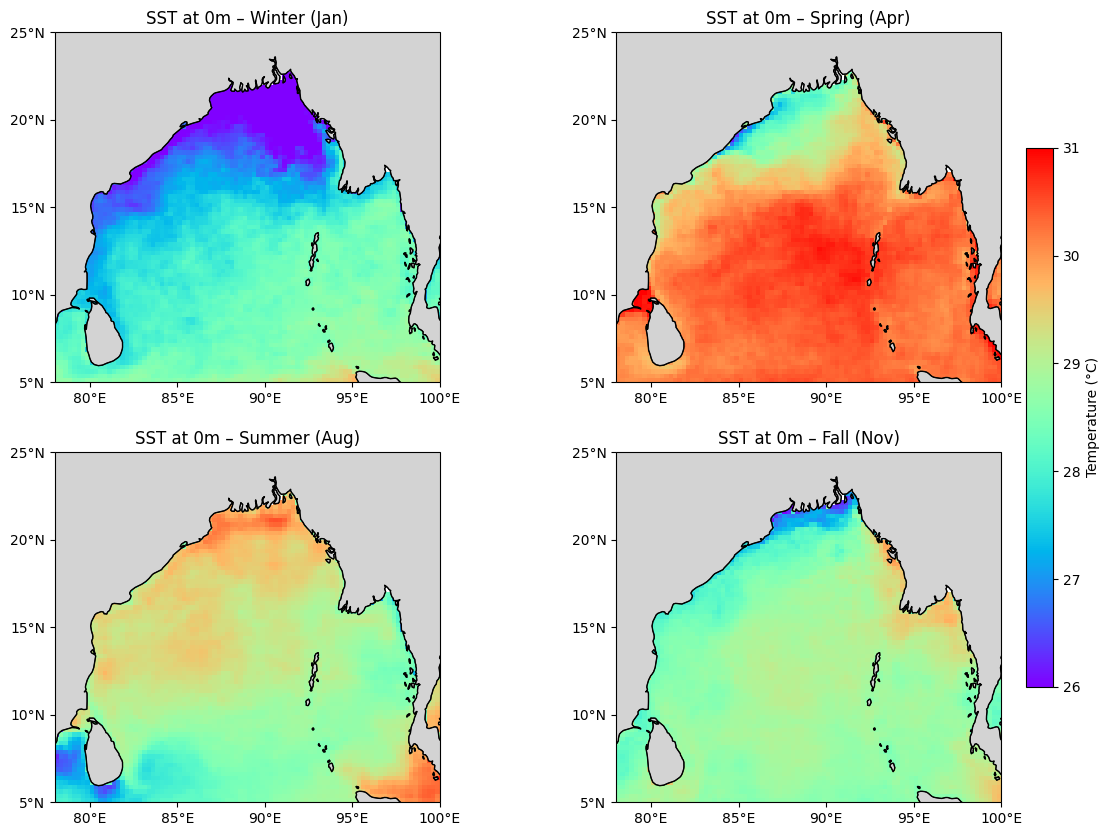

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

# Define seasonal dates
seasons = {
    'Winter (Jan)': '2022-01-01',
    'Spring (Apr)': '2022-04-01',
    'Summer (Aug)': '2022-08-01',
    'Fall (Nov)': '2022-11-01'
}

# Set up figure and map
fig, axs = plt.subplots(2, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Helper function to format each map
def format_ax(ax):
    ax.set_extent([78, 100, 5, 25], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=3)
    ax.set_xticks([80, 85, 90, 95, 100], crs=ccrs.PlateCarree())
    ax.set_yticks([5, 10, 15, 20, 25], crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())


# Plot each seasonal SST
for ax, (label, date_str) in zip(axs.flat, seasons.items()):
    temp = ds['to'].sel(time=date_str, depth=0.0, method='nearest')\
                   .sel(latitude=slice(5, 25), longitude=slice(78, 100))

    p = ax.pcolormesh(temp['longitude'], temp['latitude'], temp,
                      cmap='rainbow', shading='auto', transform=ccrs.PlateCarree(),
                      vmin=26, vmax=31, zorder=1)
    ax.set_title(f'SST at 0m – {label}', fontsize=12)
    format_ax(ax)

# Add shared colorbar
fig.colorbar(p, ax=axs, orientation='vertical', shrink=0.7, pad=0.02, label='Temperature (°C)')

plt.show()


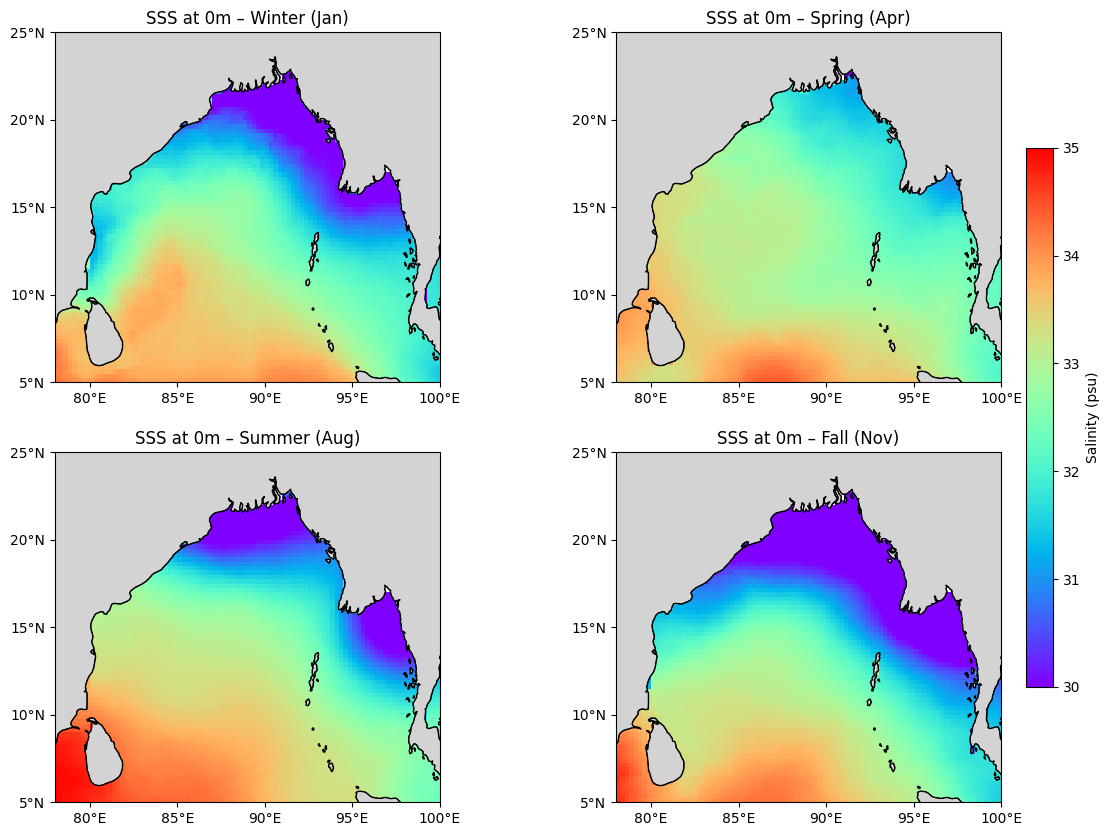

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

# Define seasonal dates
seasons = {
    'Winter (Jan)': '2022-01-01',
    'Spring (Apr)': '2022-04-01',
    'Summer (Aug)': '2022-08-01',
    'Fall (Nov)': '2022-11-01'
}

# Create the figure and axes
fig, axs = plt.subplots(2, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Helper function for formatting axes
def format_ax(ax):
    ax.set_extent([78, 100, 5, 25], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=3)
    ax.set_xticks([80, 85, 90, 95, 100], crs=ccrs.PlateCarree())
    ax.set_yticks([5, 10, 15, 20, 25], crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())


# Loop through the seasons and plot salinity
for ax, (label, date_str) in zip(axs.flat, seasons.items()):
    sal = ds['so'].sel(time=date_str, depth=0.0, method='nearest')\
                 .sel(latitude=slice(5, 25), longitude=slice(78, 100))

    p = ax.pcolormesh(sal['longitude'], sal['latitude'], sal,
                      cmap='rainbow', shading='auto', transform=ccrs.PlateCarree(),
                      vmin=30, vmax=35, zorder=1)
    ax.set_title(f'SSS at 0m – {label}', fontsize=12)
    format_ax(ax)

# Add shared colorbar
fig.colorbar(p, ax=axs, orientation='vertical', shrink=0.7, pad=0.02, label='Salinity (psu)')


plt.show()


/tmp/ipython-input-16-3143840172.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


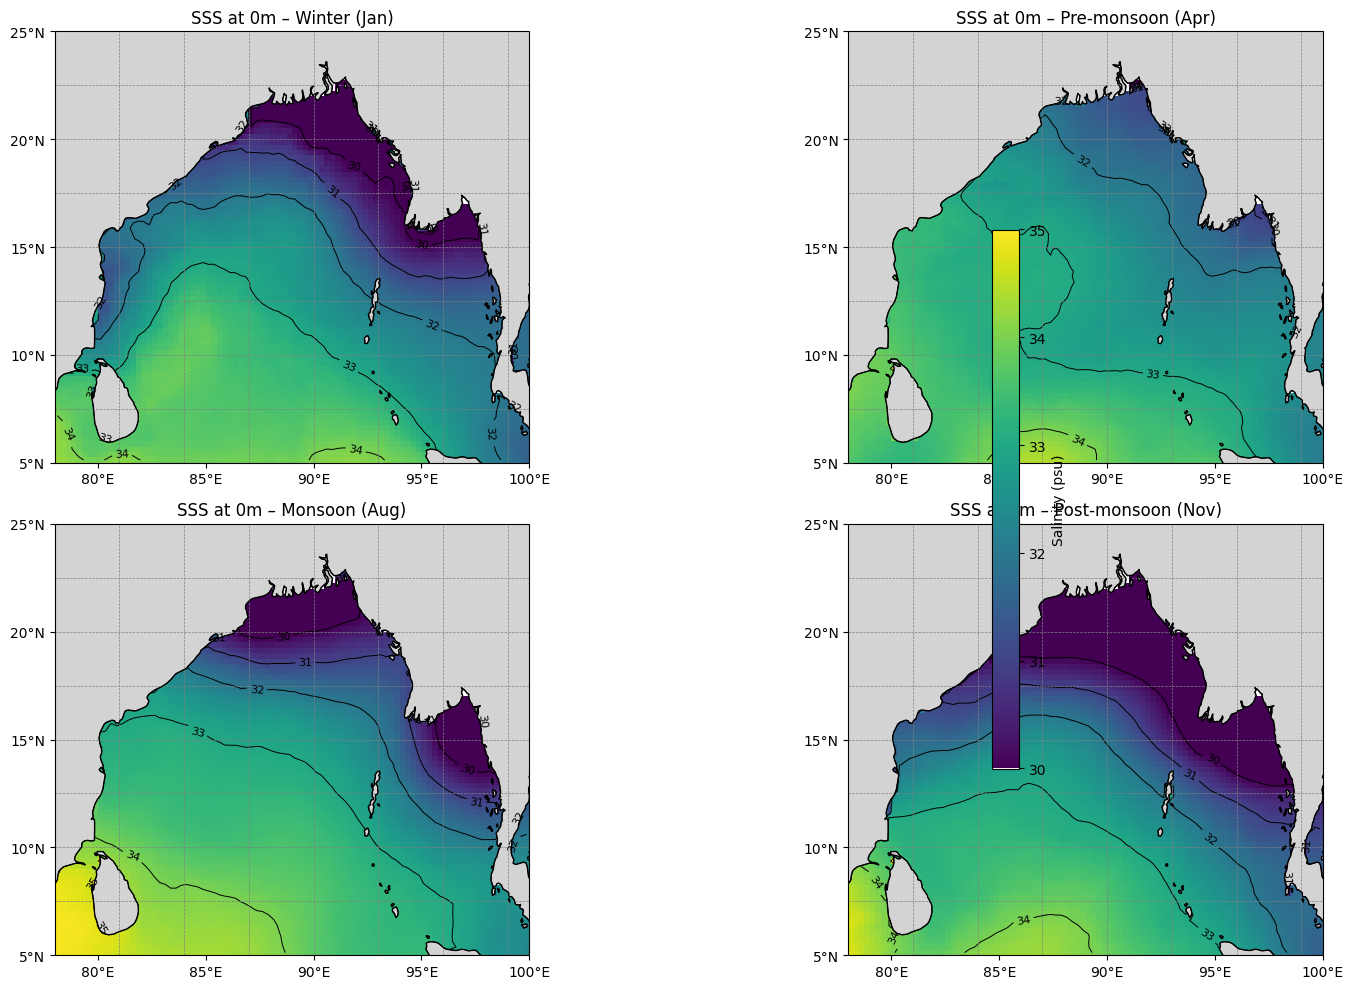

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

# Define seasonal dates
seasons = {
    'Winter (Jan)': '2022-01-01',
    'Pre-monsoon (Apr)': '2022-04-01',
    'Monsoon (Aug)': '2022-08-01',
    'Post-monsoon (Nov)': '2022-11-01'
}

# Create figure and axes
fig, axs = plt.subplots(2, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Helper for formatting axes
def format_ax(ax):
    ax.set_extent([78, 100, 5, 25], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=3)
    ax.set_xticks([80, 85, 90, 95, 100], crs=ccrs.PlateCarree())
    ax.set_yticks([5, 10, 15, 20, 25], crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.gridlines(draw_labels=False, linestyle='--', linewidth=0.5, color='gray')

# Loop through seasons
for ax, (label, date_str) in zip(axs.flat, seasons.items()):
    sal = ds['so'].sel(time=date_str, depth=0.0, method='nearest')\
                 .sel(latitude=slice(5, 25), longitude=slice(78, 100))

    # Pcolormesh
    p = ax.pcolormesh(sal['longitude'], sal['latitude'], sal,
                      cmap='viridis', shading='auto',
                      transform=ccrs.PlateCarree(), vmin=30, vmax=35, zorder=1)

    # Add contour lines
    contour = ax.contour(sal['longitude'], sal['latitude'], sal,
                         levels=range(30, 36), colors='black',
                         linewidths=0.7, transform=ccrs.PlateCarree(), zorder=2)

    ax.clabel(contour, fmt='%2.0f', fontsize=8)

    ax.set_title(f'SSS at 0m – {label}', fontsize=12)
    format_ax(ax)

# Shared colorbar
fig.colorbar(p, ax=axs, orientation='vertical', shrink=0.7, pad=0.02, label='Salinity (psu)')

plt.tight_layout()
plt.show()
